In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "solar_data_combined.csv"
)

df = pd.read_csv(DATA_PATH)

df.head()

,time,solar_irradiance,temperature,humidity,current,voltage,power,source_file,hour,calculated_power,power_difference
0,1900-01-01 08:11:00,336.72,26,94,7.59,33.17,250.48,solar_data_fri_10th.csv,8.183333,251.7603,-1.2803
1,1900-01-01 09:20:00,497.48,28,84,7.66,35.79,272.80,solar_data_fri_10th.csv,9.333333,274.1514,-1.3514
2,1900-01-01 10:06:00,736.02,30,79,8.01,36.03,286.86,solar_data_fri_10th.csv,10.100000,288.6003,-1.7403
3,1900-01-01 11:12:00,862.33,31,70,8.19,36.18,294.66,solar_data_fri_10th.csv,11.200000,296.3142,-1.6542
4,1900-01-01 12:28:00,964.65,33,59,8.20,36.31,296.45,solar_data_fri_10th.csv,12.466667,297.7420,-1.2920


In [2]:
print("Shape:", df.shape)
print()

df.info()

df.describe()

Shape: (189, 11)

<class 'pandas.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time              189 non-null    str    
 1   solar_irradiance  189 non-null    float64
 2   temperature       189 non-null    int64  
 3   humidity          189 non-null    int64  
 4   current           189 non-null    float64
 5   voltage           189 non-null    float64
 6   power             189 non-null    float64
 7   source_file       189 non-null    str    
 8   hour              189 non-null    float64
 9   calculated_power  189 non-null    float64
 10  power_difference  189 non-null    float64
dtypes: float64(7), int64(2), str(2)
memory usage: 16.4 KB


,solar_irradiance,temperature,humidity,current,voltage,power,hour,calculated_power,power_difference
count,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000
mean,783.444815,30.899471,66.592593,7.756032,33.923069,262.979735,12.233333,263.732628,-0.752892
std,255.993459,2.872365,15.736803,0.487394,1.861471,27.769456,2.588271,27.846060,1.088233
min,254.760000,24.000000,24.000000,6.300000,30.050000,189.010000,8.083333,190.071000,-3.653400
25%,568.720000,29.000000,56.000000,7.630000,32.680000,246.020000,10.200000,245.568800,-1.300000
50%,892.430000,32.000000,64.000000,7.930000,34.150000,269.960000,12.266667,270.705600,-0.938900
75%,994.560000,33.000000,79.000000,8.070000,35.510000,285.370000,14.383333,285.645600,-0.448900
max,1117.750000,36.000000,94.000000,8.390000,36.960000,300.380000,16.333333,301.154400,2.497300


In [3]:
features = [
    "solar_irradiance",
    "temperature",
    "humidity",
    "current",
    "voltage",
    "hour",
    "power",
]

correlation_matrix = df[features].corr()

correlation_matrix

,solar_irradiance,temperature,humidity,current,voltage,hour,power
solar_irradiance,1.000000,0.863601,-0.772077,0.724825,0.790648,0.844130,0.828122
temperature,0.863601,1.000000,-0.821698,0.597180,0.635980,0.839404,0.675362
humidity,-0.772077,-0.821698,1.000000,-0.536578,-0.649478,-0.775099,-0.649124
current,0.724825,0.597180,-0.536578,1.000000,0.691690,0.479085,0.924564
voltage,0.790648,0.635980,-0.649478,0.691690,1.000000,0.611309,0.912957
hour,0.844130,0.839404,-0.775099,0.479085,0.611309,1.000000,0.594971
power,0.828122,0.675362,-0.649124,0.924564,0.912957,0.594971,1.000000


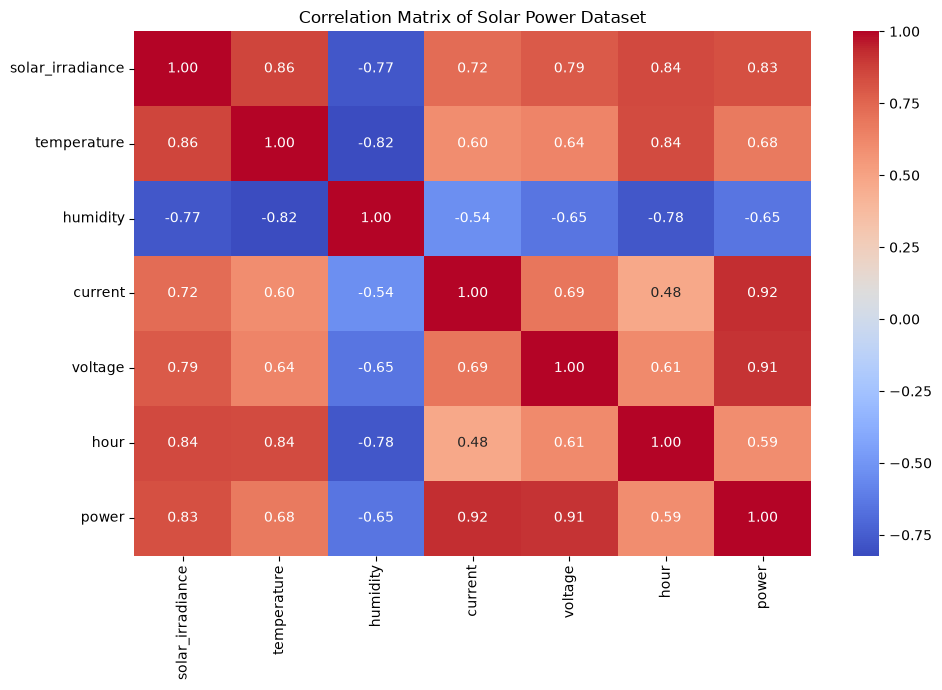

In [5]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)

plt.title("Correlation Matrix of Solar Power Dataset")
plt.tight_layout()
plt.show()

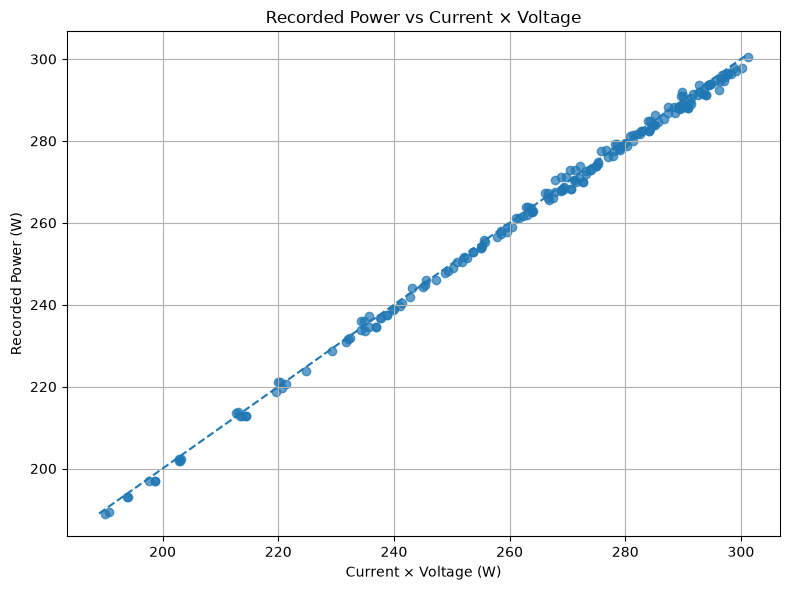

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["calculated_power"],
    df["power"],
    alpha=0.7
)

minimum = min(
    df["calculated_power"].min(),
    df["power"].min()
)

maximum = max(
    df["calculated_power"].max(),
    df["power"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Current × Voltage (W)")
plt.ylabel("Recorded Power (W)")
plt.title("Recorded Power vs Current × Voltage")
plt.grid(True)
plt.tight_layout()
plt.show()

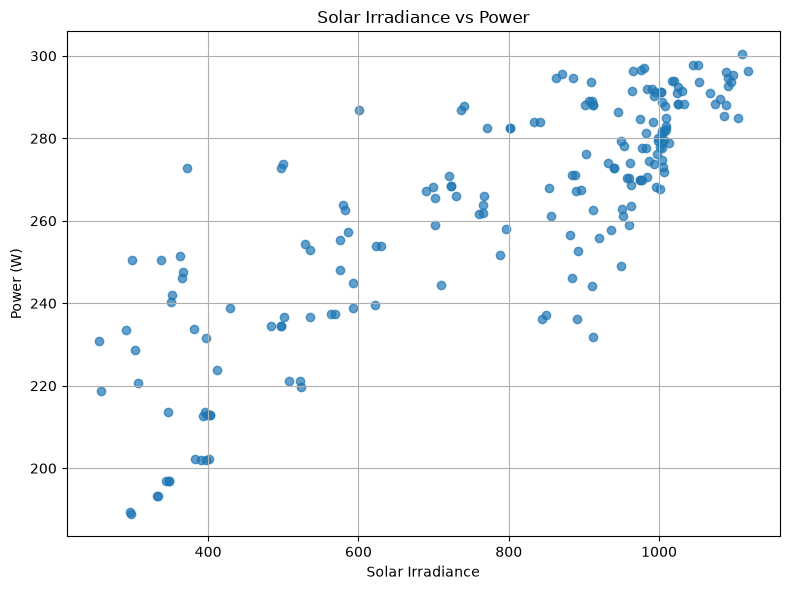

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["solar_irradiance"],
    df["power"],
    alpha=0.7
)

plt.xlabel("Solar Irradiance")
plt.ylabel("Power (W)")
plt.title("Solar Irradiance vs Power")
plt.grid(True)
plt.tight_layout()
plt.show()

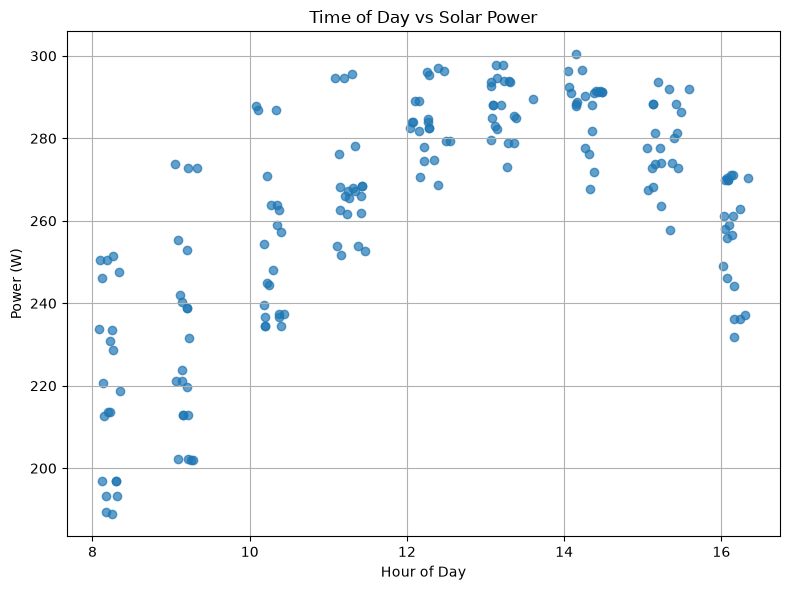

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["hour"],
    df["power"],
    alpha=0.7
)

plt.xlabel("Hour of Day")
plt.ylabel("Power (W)")
plt.title("Time of Day vs Solar Power")
plt.grid(True)
plt.tight_layout()
plt.show()

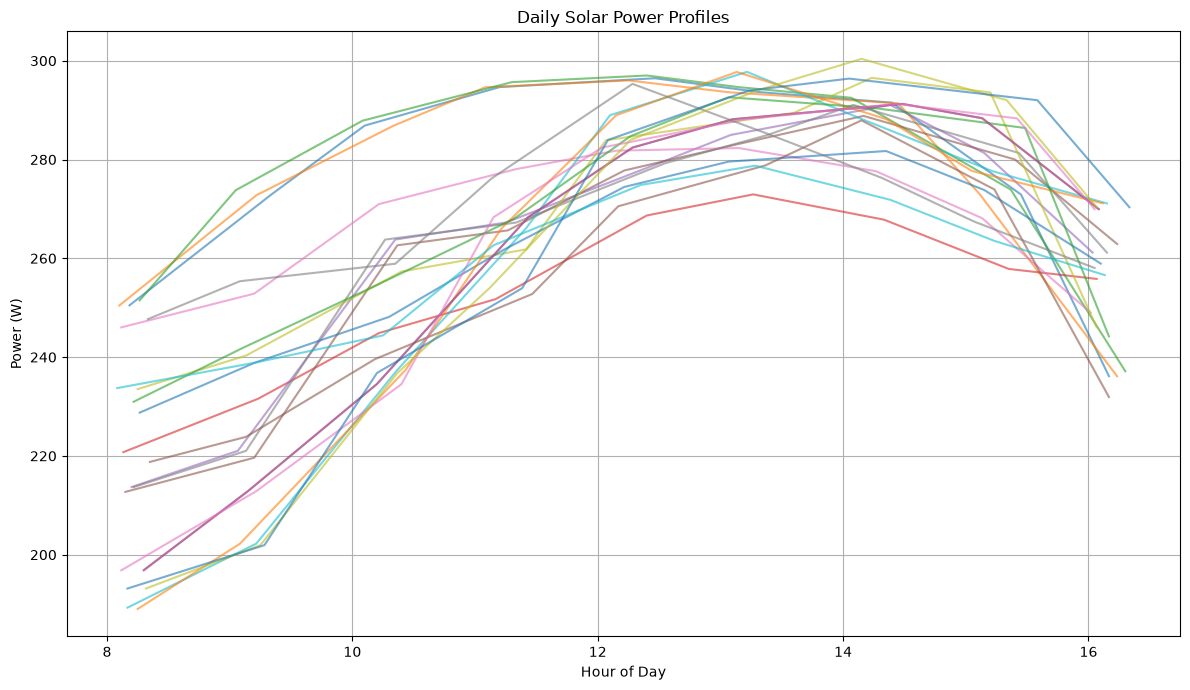

In [9]:
plt.figure(figsize=(12, 7))

for source_file, day_data in df.groupby("source_file"):
    day_data = day_data.sort_values("hour")

    plt.plot(
        day_data["hour"],
        day_data["power"],
        alpha=0.6
    )

plt.xlabel("Hour of Day")
plt.ylabel("Power (W)")
plt.title("Daily Solar Power Profiles")
plt.grid(True)
plt.tight_layout()
plt.show()